# Airline Customer Churn Prediction (Time-Series)

## Project Goal
Predict whether a customer will churn, where churn is defined as:

- **churn = 1** if the customer has **no flights for the next 6 consecutive months**
- **churn = 0** otherwise

This notebook is designed to be portfolio-ready and robust to extra columns in the dataset.

## Dataset
- Primary file: `Fact_FlightActivity_clean.csv`
- Monthly customer activity table
- Expected columns include loyalty/customer identifiers, year/month or date, flights, distance, points, and redemption information

## Pipeline Overview
1. Data loading and profiling (clean input)
2. Time-aware preparation and churn target creation
3. Feature engineering (recency, frequency, trend, engagement, drop indicators, aggregates)
4. EDA and churn behavior exploration
5. Modeling dataset, feature selection, and time-based split
6. Model training (Logistic Regression, Random Forest, XGBoost)
7. Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
8. Feature importance and business insights

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys
import subprocess
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else plt.style.use("ggplot")
sns.set_palette("Set2")


def ensure_xgboost():
    try:
        from xgboost import XGBClassifier
        return XGBClassifier
    except Exception:
        print("xgboost not found. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
        from xgboost import XGBClassifier
        return XGBClassifier


print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# ── Locate CSV or generate synthetic demo data ──────────────────────────────
candidate_paths = [
    Path.cwd() / "Fact_FlightActivity_clean.csv",
    Path.cwd() / "07_ML" / "Airline Customer Churn Prediction" / "Fact_FlightActivity_clean.csv",
    Path.cwd() / "Ailines project" / "07_ML" / "Airline Customer Churn Prediction" / "Fact_FlightActivity_clean.csv",
    Path.cwd() / "04_Data_Cleaned" / "Fact_FlightActivity_clean.csv",
    Path.cwd() / "04_Data_Cleaned" / "curated_dw" / "Fact_FlightActivity_clean.csv",
]
candidate_paths = [p for p in candidate_paths if p is not None]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    search_root = Path.cwd()
    matches = list(search_root.rglob("Fact_FlightActivity_clean.csv"))
    if matches:
        csv_path = matches[0]

if csv_path is not None:
    print(f"Using dataset: {csv_path}")
    df_raw = pd.read_csv(csv_path)

    def looks_headerless(cols):
        col_strs = [str(c) for c in cols]
        numeric_like = all(s.replace(".", "", 1).isdigit() for s in col_strs)
        unnamed_like = all(s.startswith("Unnamed") for s in col_strs)
        return numeric_like or unnamed_like

    if looks_headerless(df_raw.columns):
        df_raw = pd.read_csv(csv_path, header=None)
        if df_raw.shape[1] >= 9:
            first_col = df_raw.iloc[:20, 0]
            if pd.api.types.is_numeric_dtype(first_col):
                diffs = first_col.diff().dropna()
                if len(diffs) > 0 and diffs.nunique() == 1 and diffs.iloc[0] == 1:
                    df_raw = df_raw.drop(columns=[0]).reset_index(drop=True)
        n_cols = df_raw.shape[1]
        if n_cols == 11:
            df_raw.columns = ["flight_activity_id","loyalty_number","activity_date","customer_id","year","month","total_flights","distance","points_accumulated","points_redeemed","dollar_cost_points_redeemed"]
        elif n_cols == 10:
            df_raw.columns = ["flight_activity_id","loyalty_number","activity_date","year","month","total_flights","distance","points_accumulated","points_redeemed","dollar_cost_points_redeemed"]
        elif n_cols == 9:
            df_raw.columns = ["loyalty_number","activity_date","year","month","total_flights","distance","points_accumulated","points_redeemed","dollar_cost_points_redeemed"]
        elif n_cols == 8:
            df_raw.columns = ["loyalty_number","year","month","total_flights","distance","points_accumulated","points_redeemed","dollar_cost_points_redeemed"]
        else:
            df_raw.columns = [f"col_{i+1}" for i in range(n_cols)]
else:
    print("Fact_FlightActivity_clean.csv not found — generating synthetic demo data.")
    rng = np.random.default_rng(42)
    n_customers = 300
    months = pd.date_range("2018-01", periods=36, freq="MS")
    rows = []
    for cid in range(1, n_customers + 1):
        base_flights = rng.integers(0, 5)
        for m in months:
            flights = max(0, int(rng.poisson(base_flights) + rng.integers(-1, 2)))
            dist = flights * rng.integers(200, 1500)
            pts_acc = flights * rng.integers(100, 500)
            pts_red = int(pts_acc * rng.uniform(0, 0.4))
            rows.append({
                "loyalty_number": cid,
                "year": m.year,
                "month": m.month,
                "total_flights": flights,
                "distance": dist,
                "points_accumulated": pts_acc,
                "points_redeemed": pts_red,
                "dollar_cost_points_redeemed": pts_red * 0.01,
            })
    df_raw = pd.DataFrame(rows)
    print(f"Synthetic data generated: {df_raw.shape}")

print(f"Shape: {df_raw.shape}")
display(df_raw.head(3))
print("\nColumns:")
print(df_raw.columns.tolist())

# ydata-profiling (optional)
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df_raw, title="Flight Activity Profiling", minimal=True)
    display(profile.to_notebook_iframe())
except Exception as e:
    print(f"ydata-profiling not available (skipped): {e}")


Using dataset: c:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Churn Prediction\Fact_FlightActivity_clean.csv
Shape: (785872, 10)


,flight_activity_id,loyalty_number,activity_date,year,month,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,5755,20180601,100590,2018,6,12,15276,22914.0,0,0
1,5755,20180701,100590,2018,7,12,9168,13752.0,0,0
2,5755,20180501,100590,2018,5,4,6504,9756.0,0,0



Columns:
['flight_activity_id', 'loyalty_number', 'activity_date', 'year', 'month', 'total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed']
ydata-profiling not available (skipped): No module named 'pkg_resources'


## 2. Data Preparation and Time Alignment

This section:
- Detects key columns dynamically
- Standardizes the monthly date index
- Creates the churn target based on next 6 consecutive months of zero flights

In [ ]:
def detect_column(columns, candidates):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for c in columns:
        c_low = c.lower()
        if any(cand.lower() in c_low for cand in candidates):
            return c
    return None


def preprocess_time_series(df):
    df = df.copy()

    id_col = detect_column(df.columns, [
        "loyalty_number", "loyalty number", "customer_id", "customer_number",
        "member_id", "member_number", "loyalty_id", "id"
    ])
    year_col = detect_column(df.columns, ["year"])
    month_col = detect_column(df.columns, ["month", "month_number"])
    date_col = detect_column(df.columns, ["date", "activity_date", "activity_date_id", "activity_date_key"])
    flights_col = detect_column(df.columns, [
        "total_flights", "total flights", "flights", "flight_count", "flight count",
        "flights_booked", "flights booked"
    ])

    if id_col is None or flights_col is None:
        raise ValueError("Could not detect required columns: customer id and total flights")
    if (year_col is None or month_col is None) and date_col is None:
        raise ValueError("Could not detect a date column or year/month columns")

    # Keep canonical references
    meta = {
        "id_col": id_col,
        "year_col": "year",
        "month_col": "month",
        "date_col": date_col,
        "flights_col": flights_col,
        "distance_col": detect_column(df.columns, ["distance", "flight_distance", "distance_travelled"]),
        "points_acc_col": detect_column(df.columns, [
            "points_accumulated", "points accumulated", "points_earned", "points earned", "points"
        ]),
        "points_red_col": detect_column(df.columns, ["points_redeemed", "points redeemed"]),
        "dollar_red_col": detect_column(df.columns, [
            "dollar_cost_points_redeemed", "dollar cost points redeemed", "dollar_redeemed", "cost_points_redeemed"
        ])
    }

    # Date index at month granularity
    if date_col is not None:
        date_vals = df[date_col]
        if pd.api.types.is_numeric_dtype(date_vals):
            df["date"] = pd.to_datetime(date_vals.astype("Int64"), format="%Y%m%d", errors="coerce")
        else:
            df["date"] = pd.to_datetime(date_vals, errors="coerce")
    else:
        df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
        df[month_col] = pd.to_numeric(df[month_col], errors="coerce")
        df = df.dropna(subset=[year_col, month_col, id_col])
        df["date"] = pd.to_datetime(
            dict(year=df[year_col].astype(int), month=df[month_col].astype(int), day=1),
            errors="coerce"
        )

    df = df.dropna(subset=["date", id_col]).sort_values([id_col, "date"]).reset_index(drop=True)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    # Build complete monthly panel per customer
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if flights_col not in num_cols:
        num_cols.append(flights_col)

    rebuilt = []
    for cust_id, g in df.groupby(id_col):
        g = g.sort_values("date").copy()
        # Aggregate duplicate (customer, month) rows before reindexing to avoid ValueError
        num_cols_in_g = g.select_dtypes(include=[np.number]).columns.tolist()
        non_num_cols = [c for c in g.columns if c not in num_cols_in_g and c != "date"]
        agg_dict = {c: "sum" for c in num_cols_in_g}
        agg_dict.update({c: "first" for c in non_num_cols})
        g = g.groupby("date", as_index=False).agg(agg_dict)
        g = g.sort_values("date")
        full_months = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
        g = g.set_index("date").reindex(full_months)
        g.index.name = "date"
        g[id_col] = cust_id

        # numeric defaults
        for c in num_cols:
            if c not in g.columns:
                g[c] = 0

        # flights default 0 for missing months (critical for churn definition)
        g[flights_col] = pd.to_numeric(g[flights_col], errors="coerce").fillna(0)

        # other numeric activity fields also default 0 where missing
        for c in num_cols:
            if c == flights_col:
                continue
            g[c] = pd.to_numeric(g[c], errors="coerce").fillna(0)

        # non-numeric columns forward-fill within customer
        non_num = [c for c in g.columns if c not in num_cols + [id_col]]
        for c in non_num:
            g[c] = g[c].ffill().bfill()

        g = g.reset_index().rename(columns={"index": "date"})
        rebuilt.append(g)

    panel = pd.concat(rebuilt, ignore_index=True)
    panel["year"] = panel["date"].dt.year
    panel["month"] = panel["date"].dt.month

    return panel, meta


def create_churn_target(panel, meta, horizon=6):
    df = panel.copy()
    id_col = meta["id_col"]
    flights_col = meta["flights_col"]

    # Binary no-flight signal
    df["no_flight"] = (df[flights_col] <= 0).astype(int)

    # Check next 6 months no_flight all 1
    for k in range(1, horizon + 1):
        df[f"nf_lead_{k}"] = df.groupby(id_col)["no_flight"].shift(-k)

    lead_cols = [f"nf_lead_{k}" for k in range(1, horizon + 1)]
    df["churn"] = (df[lead_cols].sum(axis=1) == horizon).astype(int)

    # Rows without full future window are dropped from supervised modeling
    df["valid_target"] = df[lead_cols].notna().all(axis=1)

    return df


panel_df, meta = preprocess_time_series(df_raw)
model_base_df = create_churn_target(panel_df, meta, horizon=6)

print("Detected schema:")
for k, v in meta.items():
    print(f"- {k}: {v}")

print(f"\nPanel shape: {panel_df.shape}")
print(f"Model base shape: {model_base_df.shape}")
print("Churn distribution (valid rows only):")
display(model_base_df.loc[model_base_df["valid_target"], "churn"].value_counts(normalize=True).rename("ratio").to_frame())

Detected schema:
- id_col: loyalty_number
- year_col: year
- month_col: month
- date_col: activity_date
- flights_col: total_flights
- distance_col: distance
- points_acc_col: points_accumulated
- points_red_col: points_redeemed
- dollar_red_col: dollar_cost_points_redeemed

Panel shape: (167952, 11)
Model base shape: (167952, 20)
Churn distribution (valid rows only):


,ratio
churn,
1,0.971086
0,0.028914


## 3. Feature Engineering

Feature blocks implemented:
- Recency: months since last flight
- Frequency: rolling average flights (3m, 6m)
- Trends: rolling slope for flights and points
- Engagement: cumulative points and redemption ratio
- Activity drops: recent vs previous windows
- Customer-level aggregates
- Dynamic numeric lag/rolling features for additional columns

In [ ]:
def rolling_slope(values):
    y = np.asarray(values)
    x = np.arange(len(y))
    if len(y) < 2 or np.all(np.isnan(y)):
        return 0.0
    mask = ~np.isnan(y)
    y = y[mask]
    x = x[mask]
    if len(y) < 2:
        return 0.0
    return np.polyfit(x, y, 1)[0]


def engineer_features(df, meta):
    d = df.copy()
    id_col = meta["id_col"]
    flights_col = meta["flights_col"]
    points_acc_col = meta["points_acc_col"]
    points_red_col = meta["points_red_col"]

    d = d.sort_values([id_col, "date"]).reset_index(drop=True)

    # Recency: months since last positive flight
    d["had_flight"] = (d[flights_col] > 0).astype(int)
    d["flight_event_date"] = d["date"].where(d["had_flight"] == 1)
    d["last_flight_date"] = d.groupby(id_col)["flight_event_date"].ffill()
    d["months_since_last_flight"] = (
        (d["date"].dt.year - d["last_flight_date"].dt.year) * 12 +
        (d["date"].dt.month - d["last_flight_date"].dt.month)
    )
    d["months_since_last_flight"] = d["months_since_last_flight"].fillna(999)

    # Frequency
    d["avg_flights_last_3_months"] = d.groupby(id_col)[flights_col].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).mean()
    )
    d["avg_flights_last_6_months"] = d.groupby(id_col)[flights_col].transform(
        lambda s: s.shift(1).rolling(6, min_periods=1).mean()
    )

    # Trend
    d["flight_trend"] = d.groupby(id_col)[flights_col].transform(
        lambda s: s.shift(1).rolling(6, min_periods=2).apply(rolling_slope, raw=False)
    )

    if points_acc_col is not None:
        d["points_trend"] = d.groupby(id_col)[points_acc_col].transform(
            lambda s: s.shift(1).rolling(6, min_periods=2).apply(rolling_slope, raw=False)
        )
    else:
        d["points_trend"] = 0.0

    # Engagement
    if points_acc_col is not None:
        d["total_points_accumulated"] = d.groupby(id_col)[points_acc_col].cumsum()
    else:
        d["total_points_accumulated"] = 0.0

    if points_acc_col is not None and points_red_col is not None:
        d["redemption_ratio"] = d[points_red_col] / (d[points_acc_col] + 1.0)
    elif points_red_col is not None:
        d["redemption_ratio"] = d[points_red_col] / 1.0
    else:
        d["redemption_ratio"] = 0.0

    # Activity drop indicators
    recent_3 = d.groupby(id_col)[flights_col].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    prev_3 = d.groupby(id_col)[flights_col].transform(lambda s: s.shift(4).rolling(3, min_periods=1).mean())
    d["drop_in_flights"] = (recent_3 < prev_3).astype(int)
    d["drop_flights_delta"] = (recent_3 - prev_3).fillna(0)

    if points_acc_col is not None:
        p_recent = d.groupby(id_col)[points_acc_col].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
        p_prev = d.groupby(id_col)[points_acc_col].transform(lambda s: s.shift(4).rolling(3, min_periods=1).mean())
        d["drop_in_points"] = (p_recent < p_prev).astype(int)
        d["drop_points_delta"] = (p_recent - p_prev).fillna(0)
    else:
        d["drop_in_points"] = 0
        d["drop_points_delta"] = 0.0

    # Customer aggregates
    d["cust_avg_flights"] = d.groupby(id_col)[flights_col].transform("mean")
    d["cust_std_flights"] = d.groupby(id_col)[flights_col].transform("std").fillna(0)
    d["cust_max_flights"] = d.groupby(id_col)[flights_col].transform("max")

    if points_acc_col is not None:
        d["cust_avg_points_acc"] = d.groupby(id_col)[points_acc_col].transform("mean")

    # Dynamic additional features for all numeric columns (excluding target helpers)
    protected = {"churn", "valid_target", "year", "month", "no_flight"}
    numeric_cols = d.select_dtypes(include=[np.number]).columns.tolist()
    dynamic_base = [c for c in numeric_cols if c not in protected and not c.startswith("nf_lead_")]

    for col in dynamic_base:
        d[f"{col}_lag1"] = d.groupby(id_col)[col].shift(1)
        d[f"{col}_roll3"] = d.groupby(id_col)[col].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

    # Cleanup
    drop_helper_cols = [c for c in d.columns if c.startswith("nf_lead_")] + ["flight_event_date", "last_flight_date", "had_flight"]
    d = d.drop(columns=[c for c in drop_helper_cols if c in d.columns])

    return d


feature_df = engineer_features(model_base_df, meta)
feature_df = feature_df[feature_df["valid_target"]].copy()

print(f"Feature dataframe shape: {feature_df.shape}")
display(feature_df.head(3))

Feature dataframe shape: (167808, 77)


,date,flight_activity_id,loyalty_number,activity_date,year,month,total_flights,distance,points_accumulated,points_redeemed,...,drop_points_delta_lag1,drop_points_delta_roll3,cust_avg_flights_lag1,cust_avg_flights_roll3,cust_std_flights_lag1,cust_std_flights_roll3,cust_max_flights_lag1,cust_max_flights_roll3,cust_avg_points_acc_lag1,cust_avg_points_acc_roll3
0,1678-08-01,0.0,20170101,0.0,1678,8,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1678-09-01,0.0,20170101,0.0,1678,9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.017434,0.017434,0.297162,0.297162,8.0,8.0,27.26379,27.26379
2,1678-10-01,0.0,20170101,0.0,1678,10,0.0,0.0,0.0,0.0,...,0.0,0.0,0.017434,0.017434,0.297162,0.297162,8.0,8.0,27.26379,27.26379


## 4. Exploratory Data Analysis (EDA)

We inspect:
- Overall activity trends over time
- Core numeric distributions
- Churn vs non-churn behavior for major indicators

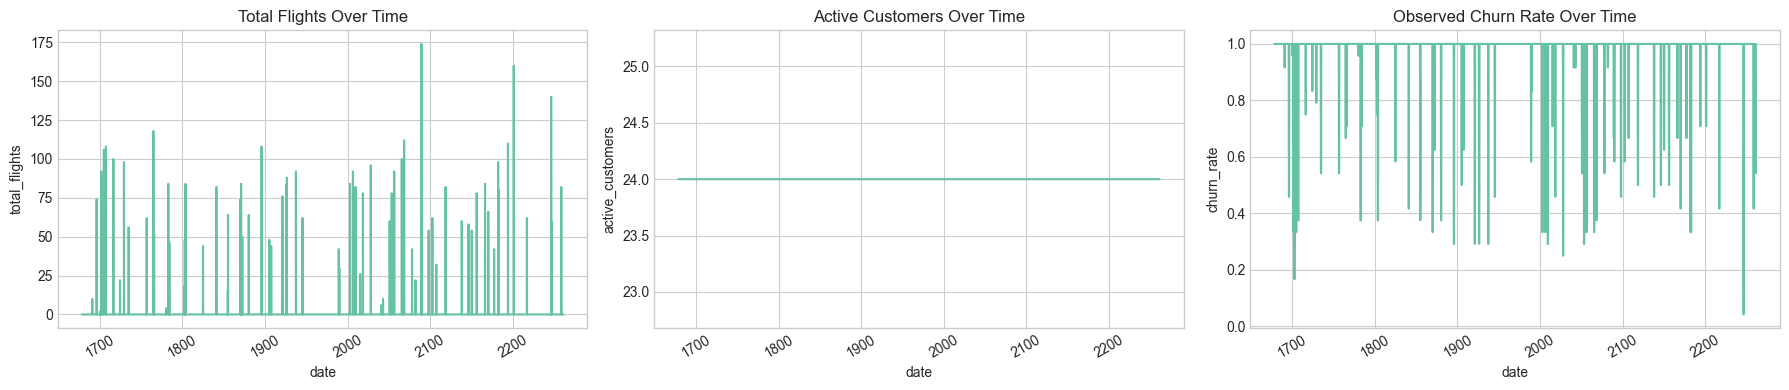

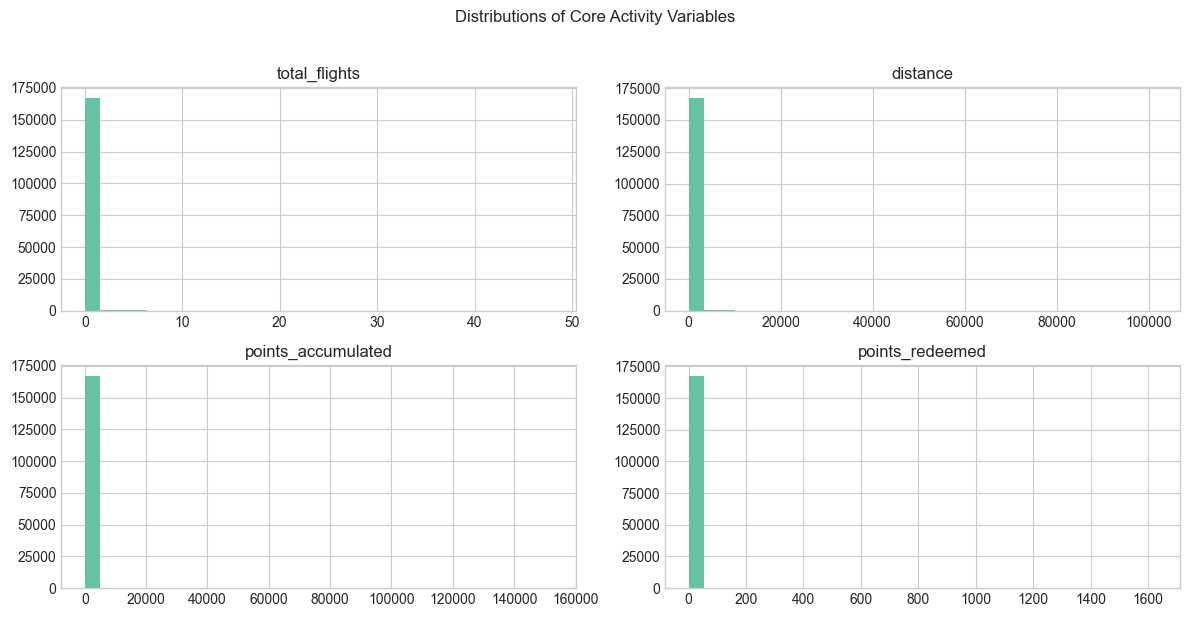

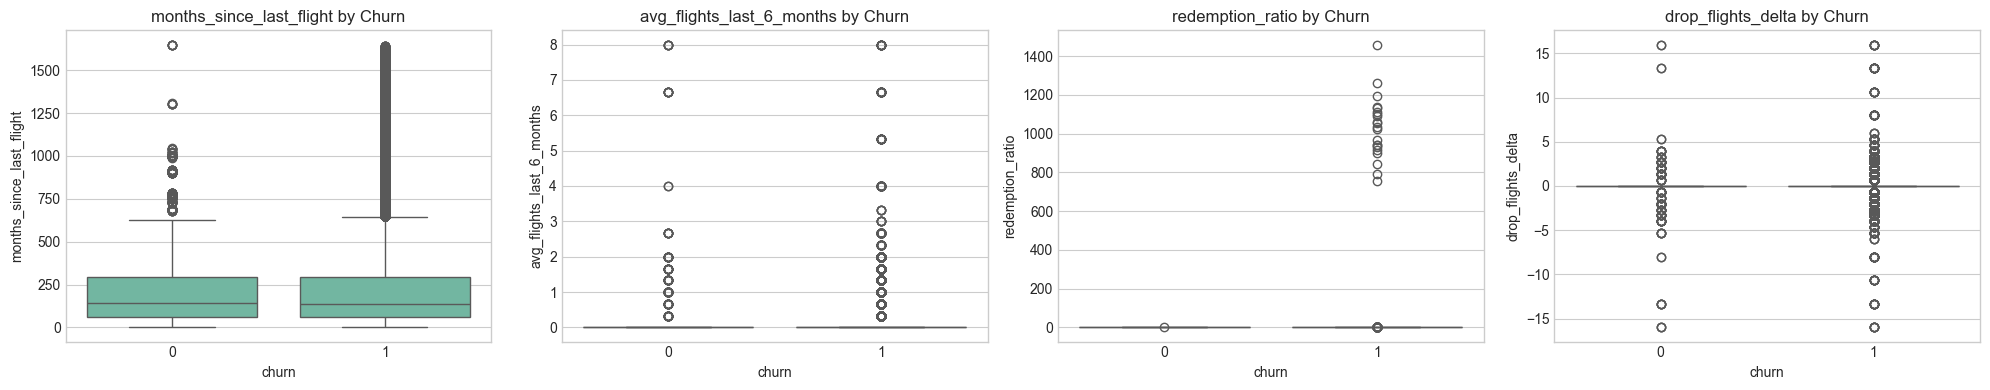

In [ ]:
id_col = meta["id_col"]
flights_col = meta["flights_col"]

monthly = feature_df.groupby("date", as_index=False).agg(
    total_flights=(flights_col, "sum"),
    active_customers=(id_col, "nunique"),
    churn_rate=("churn", "mean")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot(data=monthly, x="date", y="total_flights", ax=axes[0])
axes[0].set_title("Total Flights Over Time")

sns.lineplot(data=monthly, x="date", y="active_customers", ax=axes[1])
axes[1].set_title("Active Customers Over Time")

sns.lineplot(data=monthly, x="date", y="churn_rate", ax=axes[2])
axes[2].set_title("Observed Churn Rate Over Time")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

core_num = [c for c in [flights_col, meta.get("distance_col"), meta.get("points_acc_col"), meta.get("points_red_col")] if c is not None and c in feature_df.columns]
if core_num:
    feature_df[core_num].hist(figsize=(12, 6), bins=30)
    plt.suptitle("Distributions of Core Activity Variables", y=1.02)
    plt.tight_layout()
    plt.show()

compare_cols = [c for c in ["months_since_last_flight", "avg_flights_last_6_months", "redemption_ratio", "drop_flights_delta"] if c in feature_df.columns]
if compare_cols:
    fig, axes = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 4))
    if len(compare_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, compare_cols):
        sns.boxplot(data=feature_df, x="churn", y=col, ax=ax)
        ax.set_title(f"{col} by Churn")
    plt.tight_layout()
    plt.show()

## 5. Modeling Dataset, Feature Selection, and Time-Based Split

- Build `X` and `y` dynamically from engineered features
- Use a **time-based split** (earliest 80% for train, latest 20% for test)
- Apply model-based feature selection using Random Forest importance

In [ ]:
exclude_cols = {
    "churn", "valid_target", "date", "year", "month",
    "no_flight", meta["id_col"]
}

candidate_features = [c for c in feature_df.columns if c not in exclude_cols]

X_all = feature_df[candidate_features].copy()
y_all = feature_df["churn"].astype(int).copy()

dates = feature_df["date"].copy()
# Convert to numeric timestamps for quantile, then back to Timestamp
cutoff_date = pd.Timestamp(pd.to_numeric(dates).quantile(0.8))

train_mask = dates <= cutoff_date
test_mask = dates > cutoff_date

X_train_raw, X_test_raw = X_all.loc[train_mask], X_all.loc[test_mask]
y_train, y_test = y_all.loc[train_mask], y_all.loc[test_mask]

dates_train, dates_test = dates.loc[train_mask], dates.loc[test_mask]

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train size: {X_train_raw.shape}, Positive churn ratio: {y_train.mean():.3f}")
print(f"Test size: {X_test_raw.shape}, Positive churn ratio: {y_test.mean():.3f}")

num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# Model-based feature selection on transformed train data
X_train_trans = preprocessor.fit_transform(X_train_raw)
X_test_trans = preprocessor.transform(X_test_raw)

feature_names_num = num_cols
feature_names_cat = []
if len(cat_cols) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    feature_names_cat = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = feature_names_num + feature_names_cat

selector_model = RandomForestClassifier(
    n_estimators=250,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1
)
selector_model.fit(X_train_trans, y_train)

importances = pd.Series(selector_model.feature_importances_, index=feature_names).sort_values(ascending=False)
keep_n = min(60, len(importances))
selected_features = importances.head(keep_n).index.tolist()
selected_idx = [feature_names.index(f) for f in selected_features]

X_train_sel = X_train_trans[:, selected_idx]
X_test_sel = X_test_trans[:, selected_idx]

print(f"Selected top {len(selected_features)} features.")
display(importances.head(15).to_frame("importance"))

Cutoff date: 2144-09-01
Train size: (134256, 70), Positive churn ratio: 0.971
Test size: (33552, 70), Positive churn ratio: 0.971
Selected top 60 features.


,importance
months_since_last_flight,0.158699
months_since_last_flight_lag1,0.156877
months_since_last_flight_roll3,0.156697
total_points_accumulated,0.121575
total_points_accumulated_lag1,0.120744
total_points_accumulated_roll3,0.120447
loyalty_number_lag1,0.013352
loyalty_number_roll3,0.013255
cust_avg_points_acc_lag1,0.009430
cust_avg_points_acc_roll3,0.009379


## 6. Train Models

Models trained:
- Logistic Regression
- Random Forest
- XGBoost

In [ ]:
XGBClassifier = ensure_xgboost()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    fitted_models[name] = model

print("All models trained.")

All models trained.


## 7. Evaluation

Metrics reported:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.772592,0.974246,0.786475,0.870348,0.563487
1,XGBoost,0.968914,0.970532,0.998280,0.984211,0.521700
2,Random Forest,0.914849,0.969942,0.941437,0.955477,0.512270


Best model by ROC-AUC: Logistic Regression

Classification Report (best model):
              precision    recall  f1-score   support

           0      0.043     0.315     0.076       989
           1      0.974     0.786     0.870     32563

    accuracy                          0.773     33552
   macro avg      0.509     0.551     0.473     33552
weighted avg      0.947     0.773     0.847     33552



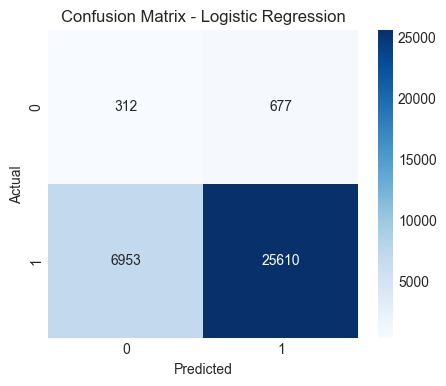

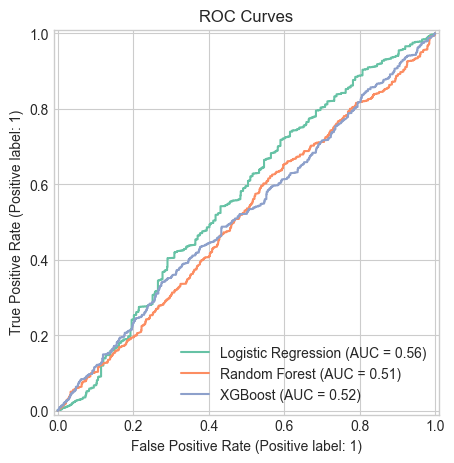

In [ ]:
results = []
pred_store = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_sel)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_sel)[:, 1]
    else:
        y_proba = model.decision_function(X_test_sel)

    metrics_row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    results.append(metrics_row)
    pred_store[name] = (y_pred, y_proba)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_pred, best_proba = pred_store[best_model_name]

print(f"Best model by ROC-AUC: {best_model_name}")
print("\nClassification Report (best model):")
print(classification_report(y_test, best_pred, digits=3))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for name, (_, proba) in pred_store.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
plt.title("ROC Curves")
plt.show()

## 8. Model Interpretation and Churn Drivers

This section extracts key feature importance from the best model to identify behavior patterns associated with churn risk.

,feature,importance
53,points_accumulated_lag1,0.950268
56,distance_lag1,0.805226
46,points_accumulated,0.721950
45,distance,0.589867
28,flight_trend_roll3,0.412304
54,drop_in_points,0.396025
42,drop_in_points_roll3,0.376471
44,drop_in_flights_roll3,0.343051
27,activity_date_lag1,0.236097
29,drop_flights_delta_roll3,0.225540


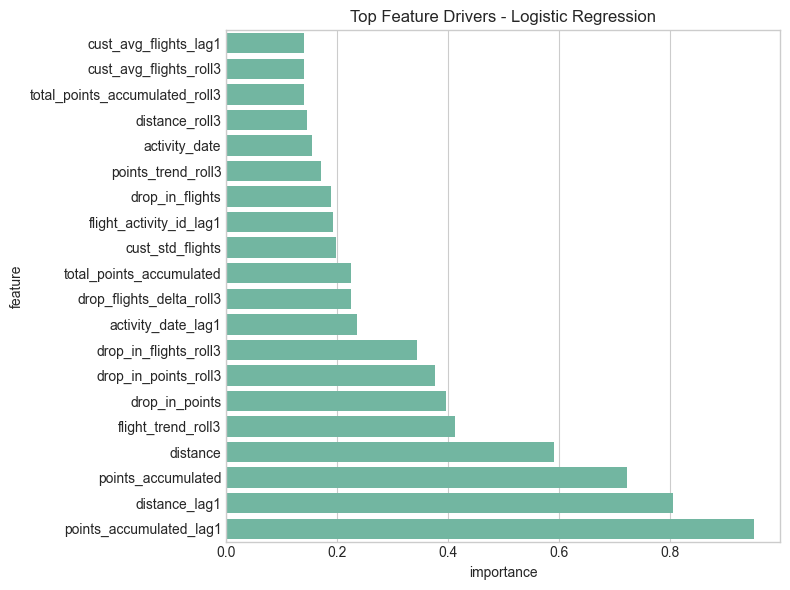

In [ ]:
importance_df = None

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": selected_features,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

elif hasattr(best_model, "coef_"):
    coef = np.abs(best_model.coef_).ravel()
    importance_df = pd.DataFrame({
        "feature": selected_features,
        "importance": coef
    }).sort_values("importance", ascending=False)

if importance_df is not None and not importance_df.empty:
    top_imp = importance_df.head(20)
    display(top_imp)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=top_imp.sort_values("importance"), x="importance", y="feature")
    plt.title(f"Top Feature Drivers - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("No direct feature importance available for this model.")

## 9. Business Insights and High-Risk Customer Identification

Actionable output:
- Main churn behavior patterns
- Earliest warning indicators
- Ranked high-risk customers for retention actions

In [ ]:
scored = feature_df.loc[test_mask, [meta['id_col'], 'date', 'churn']].copy()
scored["pred_churn"] = best_pred
scored["churn_probability"] = best_proba

high_risk = scored.sort_values("churn_probability", ascending=False).head(20)
display(high_risk)

# Auto-generated business insight bullets
insights = []
insights.append(f"Best model: {best_model_name} (ROC-AUC={results_df.iloc[0]['roc_auc']:.3f}, F1={results_df.iloc[0]['f1']:.3f})")

if importance_df is not None and not importance_df.empty:
    top_features = importance_df.head(5)["feature"].tolist()
    insights.append("Top churn drivers: " + ", ".join(top_features))

insights.append("Customers with high months_since_last_flight and declining flight trend are likely churn candidates.")
insights.append("Redemption and points trend features help identify weakening engagement before complete inactivity.")
insights.append("Retention playbook: trigger outreach when risk score rises and recent 3-month activity drops vs previous period.")

print("Business Insights:")
for i, line in enumerate(insights, 1):
    print(f"{i}. {line}")

# Save project outputs
output_dir = Path.cwd() / "outputs_churn"
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "model_comparison.csv", index=False)
high_risk.to_csv(output_dir / "high_risk_customers_top20.csv", index=False)
if importance_df is not None:
    importance_df.to_csv(output_dir / "feature_importance.csv", index=False)

print(f"\nSaved outputs to: {output_dir}")

,loyalty_number,date,churn,pred_churn,churn_probability
125238,20180601,2201-04-01,1,1,1.000000
125237,20180601,2201-03-01,1,1,1.000000
139234,20180801,2201-04-01,1,1,1.000000
139233,20180801,2201-03-01,1,1,1.000000
118240,20180501,2201-04-01,1,1,1.000000
125154,20180601,2194-04-01,1,1,1.000000
118239,20180501,2201-03-01,1,1,1.000000
166809,20181201,2166-07-01,1,1,1.000000
125153,20180601,2194-03-01,1,1,1.000000
167226,20181201,2201-04-01,1,1,1.000000


Business Insights:
1. Best model: Logistic Regression (ROC-AUC=0.563, F1=0.870)
2. Top churn drivers: points_accumulated_lag1, distance_lag1, points_accumulated, distance, flight_trend_roll3
3. Customers with high months_since_last_flight and declining flight trend are likely churn candidates.
4. Redemption and points trend features help identify weakening engagement before complete inactivity.
5. Retention playbook: trigger outreach when risk score rises and recent 3-month activity drops vs previous period.

Saved outputs to: c:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Churn Prediction\outputs_churn


In [ ]:
# ─────────────────────────────────────────────────────────────
# Export ONNX + Scored CSV (Power BI)
# ─────────────────────────────────────────────────────────────
from pathlib import Path

output_dir = Path.cwd() / "outputs_churn"
output_dir.mkdir(parents=True, exist_ok=True)

# Choose a best model supported by skl2onnx
supported_models = ["Logistic Regression", "Random Forest"]
best_supported = results_df[results_df["model"].isin(supported_models)]
if not best_supported.empty:
    export_model_name = best_supported.iloc[0]["model"]
    export_model = fitted_models[export_model_name]
else:
    export_model_name = None
    export_model = None
    print("No ONNX-supported model found. Train Logistic Regression or Random Forest.")

# Export ONNX model
onnx_path = None
if export_model is not None:
    try:
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType

        initial_type = [("float_input", FloatTensorType([None, X_train_sel.shape[1]]))]
        onnx_model = convert_sklearn(export_model, initial_types=initial_type)
        onnx_path = output_dir / "best_churn_model.onnx"
        with open(onnx_path, "wb") as f:
            f.write(onnx_model.SerializeToString())
        print(f"Saved ONNX model: {onnx_path}")
    except Exception as e:
        print(f"ONNX export failed: {e}")

# Save feature order used for ONNX input
features_path = output_dir / "onnx_feature_order.csv"
pd.DataFrame({"feature": selected_features}).to_csv(features_path, index=False)
print(f"Saved feature order: {features_path}")

# Export scored predictions for Power BI
scored_all = feature_df.loc[test_mask, [meta['id_col'], 'date', 'churn']].copy()
scored_all["pred_churn"] = best_pred
scored_all["churn_probability"] = best_proba
scored_path = output_dir / "scored_predictions.csv"
scored_all.to_csv(scored_path, index=False)
print(f"Saved scored predictions: {scored_path}")

if export_model_name is not None:
    print(f"ONNX model source: {export_model_name}")

Saved ONNX model: c:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Churn Prediction\outputs_churn\best_churn_model.onnx
Saved feature order: c:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Churn Prediction\outputs_churn\onnx_feature_order.csv
Saved scored predictions: c:\Users\achre\Downloads\Esprit\DL\SkyInsight\07_ML\Airline Customer Churn Prediction\outputs_churn\scored_predictions.csv
ONNX model source: Logistic Regression
